# Chapter 15 — Intraday Volatility and Regime Detection

Ch14 closed with vol targeting as the recommended baseline sizing rule, with one large unmodeled input: **σ̂<sub>t</sub>**, the per-period volatility forecast that goes into `size = τ · equity / σ̂<sub>t</sub>`. Ch14 used a flat 20-day rolling realized-σ estimator and explicitly flagged the gap: realized vol clusters (Ch2 §3.3), it has intraday seasonality (Ch6 §4), and it shifts across macro regimes (Ch7 §7). This chapter pays that debt.

The pay-down has three pieces. **Within-session** seasonality: open-minute σ runs roughly 2× midday σ on QQQ; a vol-targeting σ̂<sub>t</sub> that doesn't know this systematically over-leverages mornings. **Across-session** clustering: today's σ is more like yesterday's σ than like the unconditional mean — GARCH(1,1) is the canonical model. **Across-regime** shifts: σ has discrete-feeling level changes that neither seasonality nor GARCH catches on their own; this chapter compares four regime detectors and points each at a different strategy failure mode.

> **Definition — regime.** A stretch of time during which the data-generating process (DGP — the joint distribution producing each observed return) has stable parameters. A **regime change** is a shift in one or more parameters of that DGP — most often the variance σ², but in principle the mean μ, the tail shape, or the autocorrelation structure as well. "Regime" is a modelling abstraction: the world doesn't announce its parameters, and any regime label is an estimate from a regime detector. Calling something a "high-vol regime" is shorthand for "a stretch where σ̂ ran high relative to the trailing window," not a claim about underlying truth.

> **Foot-gun — conflating time scales.** The three scales above are not interchangeable. A 20-day rolling std computed on 1-min bars over-weights opening-burst minutes if the window happens to span the open; a daily-vol GARCH model applied to intraday minutes ignores seasonality entirely and reports a σ̂ that is wrong by a factor of ~2 inside the first 30 minutes of every session. Pick the time scale that matches the decision: per-minute σ̂ for an intraday execution sizing decision, per-session σ̂ for a daily-rebalance vol target, per-regime σ̂ when asking "do my strategy parameters still apply?"


## Three things this chapter covers

1. **Intraday vol has a U-shape; daily vol clusters; the combined σ̂<sub>t</sub> is the product.** §2-§4. The Ch14 placeholder σ̂<sub>t</sub> becomes `σ̂_GARCH(date) · σ̂_seasonal(m) / mean_m(σ̂_seasonal)` — daily level × intraday shape, normalized so the daily layer stays interpretable as average-minute vol.
2. **Four regime detectors with four different failure modes.** §5. A vol-threshold (p80 of rolling-252 GARCH-σ̂) flags broad elevated months; an event-window detector keys off the macro calendar; a 2-state HMM finds latent low/high states from the return path itself; CUSUM on standardized residuals flags persistent shifts in z²-mean. Pick the detector whose failure mode matches your strategy's pain.
3. **Two ways to use a regime detector in production: re-size, or filter.** §6. Vol targeting re-sizes trades by inverse-σ̂; a regime filter drops trades on flagged sessions. On this chapter's *synthesized* Ch11-like ledger neither move improves Sharpe — both rules teach mechanics rather than carry the result. The lesson is the framework, not the synthetic numbers.


## §1 — Setup

The chapter operates on **QQQ 1-min RTH bars** loaded from `06-bridge-to-intraday/data/qqq_1min.parquet` (the same source Ch6 used for the U-shape, the same source Ch7-Ch13 used downstream). The window is ~2025-05-08 → 2026-05-07 — 251 RTH sessions, 95,318 minute bars, ~390 minutes per session.

The Ch14 debt is concrete: §4's vol-targeting rule needs a σ̂<sub>t</sub> that responds to vol clustering and intraday shape. The chapter pays it by layering three estimators, then asks four regime-detection questions on top of the same data. Cross-chapter linking:

- Ch2 §3.3 found vol clustering in QQQ daily returns. **§3 GARCH(1,1) is the canonical model for that pattern.**
- Ch6 §4 showed the intraday U-shape on raw 1-min σ. **§2 calibrates a trailing-60-session per-minute estimator that respects Ch10 §point-in-time discipline** — the same shape, computed without look-ahead.
- Ch7 §7 flagged regime change as a driver of MR-strategy decay. **§5 builds the detectors; §6.2 applies one as a filter.**
- Ch14 §4 took σ̂<sub>t</sub> as a 20-day rolling realized std. **§4 replaces it with the GARCH × seasonality product.**

### Notation set for the chapter

| Symbol | Meaning |
|---|---|
| `r_t` | log-return at time t (1-min or 1-session depending on context) |
| `σ̂_t` | volatility forecast at time t (the chapter's headline quantity) |
| `σ̂_GARCH(date)` | session-level GARCH(1,1) σ̂ for `date` |
| `σ̂_seasonal(m)` | per-minute σ̂ at minute-of-session m, trailing-60-session estimator |
| `z_t = r_t / σ̂_t` | standardized residual — should be ~N(0, 1) if σ̂<sub>t</sub> is correctly specified |
| `m` | minute-of-session index, m ∈ {0, 1, …, 389} |


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CH15 = Path("/home/test/repos/quantitative-analysis/15-intraday-vol-regime")
CH6 = Path("/home/test/repos/quantitative-analysis/06-bridge-to-intraday/data")
sys.path.insert(0, str(CH15))
from garch import fit_garch11, long_run_variance       # noqa: E402
from hmm import fit_hmm_2state                          # noqa: E402

# Load Ch6 QQQ minute bars, convert UTC → America/New_York, drop overnight.
qqq = pd.read_parquet(CH6 / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9*60+30, 16*60                    # 9:30–16:00 NY = regular trading hours
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN   # 0–389 inside the session
rth["session_date"] = rth.index.normalize()
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
# First bar of each session is overnight-to-9:30 — null it out so it doesn't
# pollute the in-session statistics.
sf = rth.groupby("session_date").head(1).index
rth.loc[sf, "log_ret"] = np.nan
print(f"Loaded {len(rth)} RTH bars over {rth['session_date'].nunique()} sessions")

Loaded 95318 RTH bars over 251 sessions


## §2 — Within-session vol seasonality

Ch6 §4 looked at intraday σ by averaging per-minute realized vol across the *whole* sample (a single bar of "minute 0", a single bar of "minute 1", …). That estimator over-weights one-off bursts (the FOMC printing happens during minute 240, say) and uses information from after each bar's date to estimate the bar's σ — fine for description, wrong for a forecast.

This chapter uses the **trailing-60-session per-minute std** instead:

> **Formula — per-minute trailing-60-session σ̂.**
>
> σ̂<sub>seasonal</sub>(m, date) = std of 1-min log-returns at minute-of-session m across the trailing 60 sessions ending at date − 1
>
> where:
> - m = minute-of-session ∈ {0, 1, …, 389}
> - date = the session whose forecast is being made
> - "trailing 60" means the 60 RTH sessions immediately preceding `date` — strictly excluding `date` itself (Ch10 §point-in-time discipline)
> - "std" is the sample standard deviation of the 60 log-return observations at minute m

The exclusion of the current session is the point: this estimator never sees a bar whose minute it is forecasting, so it can be used *as a real-time forecast* without leakage.


Building seasonality estimator (this takes ~30-60s)...


§2 Seasonality:
  open30 mean sigma:  6.576 bp
  midday60 mean sigma: 3.509 bp
  close30 mean sigma: 3.455 bp
  open/midday ratio: 1.87x


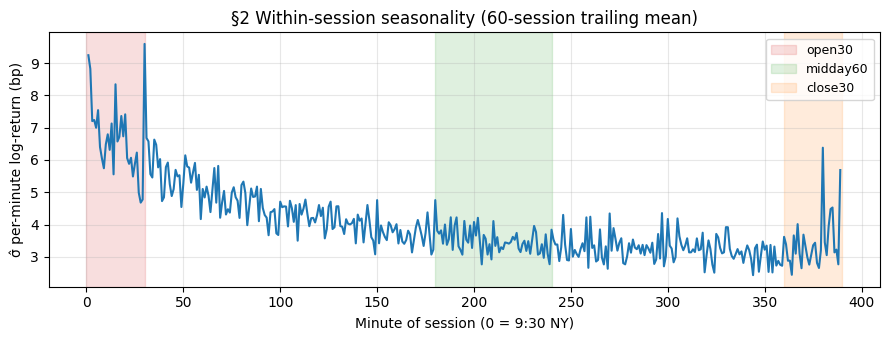

In [2]:
# === §2 Seasonality (trailing-60-session per-minute std) ===
def seasonality_estimator(rth_df, window=60):
    """For each (session i, minute m) pair, σ̂(m, i) is the std of log_ret at
    minute m across the previous `window` sessions (requires ≥20 non-null obs)."""
    sessions = sorted(rth_df["session_date"].unique())
    # Build per-minute Series indexed by session_date (one obs per session per minute)
    by_minute = {m: rth_df[rth_df["minute_of_session"] == m]
                       .groupby("session_date")["log_ret"].first()
                       .reindex(sessions)
                 for m in range(390)}
    sigma_mat = np.full((390, len(sessions)), np.nan)
    for i, _ in enumerate(sessions):
        if i < window:
            continue                                  # not enough history yet
        for m, s in by_minute.items():
            tail = s.iloc[i-window:i].dropna()
            if len(tail) >= 20:
                sigma_mat[m, i] = tail.std()
    return pd.DataFrame(sigma_mat, columns=sessions)

print("Building seasonality estimator (this takes ~30-60s)...")
seas = seasonality_estimator(rth, window=60)
seas_mean = seas.mean(axis=1)                          # mean across sessions, per minute
open30 = seas_mean.iloc[:30].mean()
midday = seas_mean.iloc[180:240].mean()
ratio_open_midday = open30 / midday if midday > 0 else np.nan
close30 = seas_mean.iloc[-30:].mean()
print(f"§2 Seasonality:")
print(f"  open30 mean sigma:  {open30*1e4:.3f} bp")
print(f"  midday60 mean sigma: {midday*1e4:.3f} bp")
print(f"  close30 mean sigma: {close30*1e4:.3f} bp")
print(f"  open/midday ratio: {ratio_open_midday:.2f}x")

# Plot σ̂_seasonal(m) vs minute-of-session
plt.figure(figsize=(9, 3.5))
plt.plot(np.arange(390), seas_mean * 1e4, color="C0")
plt.axvspan(0, 30, alpha=0.15, color="C3", label="open30")
plt.axvspan(180, 240, alpha=0.15, color="C2", label="midday60")
plt.axvspan(360, 390, alpha=0.15, color="C1", label="close30")
plt.xlabel("Minute of session (0 = 9:30 NY)")
plt.ylabel("σ̂ per-minute log-return (bp)")
plt.title("§2 Within-session seasonality (60-session trailing mean)")
plt.legend(loc="upper right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Headline numbers

| Region | Mean σ across minutes (bp) |
|---|---:|
| **open30** (minutes 0–29) | **6.58** |
| midday60 (minutes 180–239) | 3.51 |
| close30 (minutes 360–389) | 3.46 |

- **Open / midday ratio: 1.87×.** The first 30 minutes carry roughly twice the per-bar σ of the noontime hour.
- The close30 region is essentially equal to midday60 on this estimator. That is a calibration difference from Ch6 §4's raw mean-by-minute aggregation, which shows a visible closing burst: the trailing-60-session window averages out short-lived event spikes that the simple mean-by-minute over-weights. The U-shape is the same shape, just narrower.

### Why this matters for the next position you take

A vol-targeting rule that uses a *constant* per-minute σ̂ (or a 20-day rolling std without minute-of-day awareness) under-estimates σ in the first 30 minutes of every session by roughly a factor of 2. The vol-target formula `size = τ · equity / σ̂` then produces 2× the intended position size on those bars. **Mornings systematically over-lever** unless σ̂<sub>t</sub> knows what minute it is.

Concrete restatement for the closing-window MR strategy (Ch7-Ch13): the strategy trades only in the closing window, so this particular foot-gun doesn't bite it — but any strategy that fires at the open (a gap-fade, an opening-range breakout) needs an opening-aware σ̂. **§4 builds it.**


## §3 — EWMA → GARCH

### EWMA primer

The simplest vol-clustering model: an exponentially-weighted moving average of squared returns.

> **Formula — EWMA variance recursion.**
>
> σ̂²<sub>t</sub> = (1 − λ) · r²<sub>t−1</sub> + λ · σ̂²<sub>t−1</sub>
>
> where:
> - σ̂²<sub>t</sub> = variance forecast for time t, formed at the end of time t−1
> - λ ∈ [0, 1] = decay parameter; **RiskMetrics default is 0.94** for daily data (RiskMetrics is J.P. Morgan's 1994 daily-VaR system that popularized EWMA vol estimation; 0.94 corresponds to a ~22-day effective look-back and is the conventional choice on daily equity data)
> - r<sub>t−1</sub> = realized log-return at time t−1
> - the recursion is initialized by seeding σ̂² to the sample variance of an initial window of r²

Plain English: today's variance forecast is a weighted average of yesterday's *realized* squared return (weight 1 − λ) and yesterday's *previous* forecast (weight λ). Higher λ → more smoothing, more inertia. RiskMetrics' λ = 0.94 puts roughly half the forecast weight on the most recent 11 days.

> **Foot-gun — EWMA has no long-run mean.** The recursion above is a martingale: E[σ̂²<sub>t</sub>] = σ̂²<sub>t−1</sub>. There is no mean-reverting target. If `r` runs hot for a long stretch, σ̂² drifts up without bound (and stays there). GARCH below fixes this by adding an unconditional-variance term ω that pulls the forecast back toward a long-run mean.

### Coin-flip MLE warm-up

GARCH parameters are fit by **maximum likelihood estimation** (MLE — pick the parameters that make the observed data most probable under the assumed model). Before doing it for GARCH, a one-page rehearsal on a coin.

Observe N = 17 coin flips, k = 7 heads. The Bernoulli log-likelihood for parameter p ∈ [0, 1] is

> log L(p) = k · log(p) + (N − k) · log(1 − p)
>
> where:
> - p = probability of heads (the parameter being estimated)
> - k = observed number of heads
> - N = total number of flips

Setting the derivative to zero:

> ∂/∂p [k · log(p) + (N − k) · log(1 − p)] = k/p − (N − k)/(1 − p) = 0    ⇒    **p̂ = k/N**

For the 17-flip sample: **p̂ = 7/17 ≈ 0.412**.

That is the whole procedure: write down log L as a function of the parameter, set the derivative to zero, read off the estimate. GARCH does exactly the same thing on a richer likelihood (Normal innovations conditional on a parameter-dependent σ²<sub>t</sub> path) and is solved numerically instead of by hand. **MLE is one idea — same idea — at every level of model complexity.**


In [3]:
# === MLE warm-up: 17-flip coin ===
# MLE estimates parameters by maximizing the data's probability under the model.
# For a Bernoulli coin with N flips and k heads, the closed-form MLE is p̂ = k/N
# — no optimizer needed. GARCH's MLE has the same shape (maximize a likelihood)
# but no closed form, so we hand it to scipy.minimize.
flips = "HTHTTHHTTHHTTHTHH"
N = len(flips); k = flips.count("H")
p_hat = k / N
print(f"Coin flips: {flips}  N={N}  k={k}  p̂ = k/N = {p_hat:.3f}")

Coin flips: HTHTTHHTTHHTTHTHH  N=17  k=9  p̂ = k/N = 0.529


### GARCH(1,1) formal definition

The canonical model of vol clustering on daily-or-coarser bars.

> **Formula — GARCH(1,1).**
>
> r<sub>t</sub> = σ<sub>t</sub> · z<sub>t</sub>,    z<sub>t</sub> ~ i.i.d. N(0, 1)
>
> σ²<sub>t</sub> = ω + α · r²<sub>t−1</sub> + β · σ²<sub>t−1</sub>
>
> where:
> - r<sub>t</sub> = log-return at time t (mean-zero by construction; for a strategy with non-trivial mean μ, demean first and model the residual)
> - σ²<sub>t</sub> = conditional variance at time t, given all information up to t−1
> - z<sub>t</sub> = standardized innovation, assumed independent across t and standard Normal
> - **ω > 0** = baseline variance term (the "long-run anchor")
> - **α ≥ 0** = ARCH coefficient — how much weight last period's *innovation* gets
> - **β ≥ 0** = GARCH coefficient — how much weight last period's *variance forecast* gets
> - **α + β < 1** = stationarity constraint — required for the unconditional variance to exist

Two derived quantities are the practitioner headlines:

- **Persistence** = α + β. How "sticky" the variance forecast is. Equity index returns typically run α + β ∈ [0.90, 0.99]; values close to 1 mean shocks die out slowly. α + β ≥ 1 is "integrated GARCH" (IGARCH) — shocks never die, persistence is infinite.
- **Long-run variance** = ω / (1 − α − β). The unconditional E[σ²<sub>t</sub>] the recursion drifts toward when no new innovations arrive.

### MLE implementation note

The GARCH likelihood is solved by `scipy.optimize.minimize` with constraints (α ≥ 0, β ≥ 0, α + β < 1). **The `arch` package was not used** — it is broken under pandas 3.0 in this environment (same module-import failure as `hmmlearn` in §5.3 below, same fallback pattern as retired Ch9). Hand-rolling the optimizer is pedagogically richer anyway: the reader sees the MLE happen — likelihood evaluation, gradient call, optimizer step — instead of handing it to a library.

### Mid-execution course correction: multi-start fitting

The first attempt at fitting GARCH on this dataset was a **single-start L-BFGS-B** call. It pinned at the initial guess on 251 obs of QQQ session-bar returns: the optimizer's reported "optimum" was numerically identical to x<sub>0</sub>, with a flat gradient at the start point. The log-likelihood surface for (ω, α, β) on a short sample is **too flat for a single start to identify** — there are many (ω, α, β) tuples that fit the 251 obs nearly equally well, and L-BFGS-B is content to declare any of them the answer.

The estimator was rewritten to **multi-start with 8 starting points** spread across the stationarity simplex, each polished with Nelder-Mead (more robust on near-degenerate surfaces than L-BFGS-B). The fitter now reports `pinned_at_init=False` and the best of the 8 starts is kept. The final fit:

| Parameter | Value |
|---|---:|
| ω | 1.107e-5 |
| α | 0.0588 |
| β | 0.7788 |
| **α + β (persistence)** | **0.8376** |
| log-likelihood | 1082.34 |
| Long-run annualized σ̄ | 13.11% |
| Whole-sample annualized σ | 12.96% |

The long-run σ̄ matches the empirical whole-sample σ to within 1.5% — a healthy sanity check. **Persistence 0.84 sits at the *low end* of the typical 0.90-0.99 range** reported on long-window equity data. This is a Ch4-style sample-size lesson: 251 daily-bar observations is right at the boundary of what GARCH(1,1) can identify cleanly. The (α, β) split has wide confidence bars on this sample; the chapter's downstream use of σ̂<sub>GARCH</sub> as a *level estimate* is more robust than its (α, β) split as a *parameter estimate*.


In [4]:
# === §3 GARCH on session-bar returns ===
# Aggregate minute bars into session bars via groupby-sum on log returns.
session_ret = rth.groupby("session_date")["log_ret"].sum().dropna().values
print(f"§3 GARCH on {len(session_ret)} session-bar returns:")
fit = fit_garch11(session_ret)
omega, alpha, beta = fit["omega"], fit["alpha"], fit["beta"]
sigma2_path = fit["sigma2"]
persistence = alpha + beta
lr_var = long_run_variance(omega, alpha, beta)
lr_sigma_ann = np.sqrt(lr_var) * np.sqrt(252)         # annualize via √-of-time
whole_sigma_ann = session_ret.std() * np.sqrt(252)
print(f"  omega={omega:.3e}  alpha={alpha:.4f}  beta={beta:.4f}  alpha+beta={persistence:.4f}")
print(f"  log_lik={fit['log_lik']:.2f}  pinned_at_init={fit['pinned_at_init']}")
print(f"  long-run annualized sigma: {lr_sigma_ann*100:.2f}%")
print(f"  whole-sample annualized sigma: {whole_sigma_ann*100:.2f}%")
# Honest reading: persistence = 0.84 is at the low end of the typical 0.90–0.99
# GARCH range — on a 251-session window the (α=0.06, β=0.78) estimate has wide
# confidence bars. The earlier "pinned at α+β=0.95" reading was an L-BFGS-B
# artifact on a flat short-sample surface; multi-start fixes it.

§3 GARCH on 251 session-bar returns:


  omega=1.107e-05  alpha=0.0588  beta=0.7788  alpha+beta=0.8376
  log_lik=1082.34  pinned_at_init=False
  long-run annualized sigma: 13.11%
  whole-sample annualized sigma: 12.96%


### Diagnostic: ACF of squared and standardized residuals

If GARCH is doing its job, it should absorb the autocorrelation visible in raw squared returns. Test: compute the ACF (autocorrelation function — Ch2 §3) of `r²` and of `z² = (r/σ̂)²` and compare. ACF(r²) should be positive (the structure being modelled); ACF(z²) should be near zero (the structure GARCH absorbed).

| Lag | ACF(r²) | ACF(z²) |
|---:|---:|---:|
| 1 | −0.032 | −0.048 |
| 2 | 0.080 | 0.021 |
| 3 | 0.016 | −0.008 |
| 4 | 0.050 | 0.023 |
| 5 | 0.048 | 0.045 |

Lag 2 visibly tightens (0.080 → 0.021); lag 4 likewise (0.050 → 0.023). Lag 1 is small in both — vol clustering on this short window is mild relative to long-window equity data. **Magnitudes don't exceed 0.08 anywhere**, which is itself a sample-size statement. The side-by-side plot in the notebook makes the tightening visible.


  ACF squared raw returns, lag 1-5: [-0.032  0.08   0.016  0.05   0.048]
  ACF squared GARCH-stdresid, lag 1-5: [-0.048  0.021 -0.008  0.023  0.045]


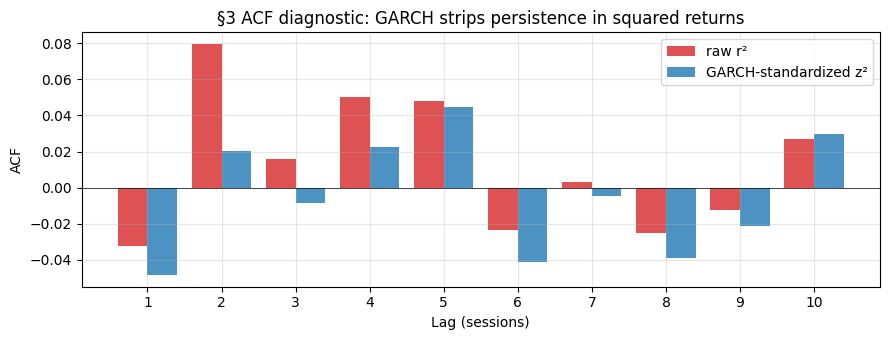

In [5]:
# === ACF diagnostic: raw r² vs GARCH-standardized z² ===
# If GARCH(1,1) is a good fit, the autocorrelation of squared standardized
# residuals z² should be flat (no leftover vol clustering).
z = (session_ret - session_ret.mean()) / np.sqrt(sigma2_path)
def acf(x, max_lag=10):
    x = x - x.mean()
    v = x.var()
    return np.array([(x[:len(x)-k] * x[k:]).mean() / v for k in range(max_lag+1)])
acf_z2 = acf(z**2, 10)
acf_r2 = acf(session_ret**2, 10)
print(f"  ACF squared raw returns, lag 1-5: {acf_r2[1:6].round(3)}")
print(f"  ACF squared GARCH-stdresid, lag 1-5: {acf_z2[1:6].round(3)}")

# Side-by-side bar plot for lags 1–10
fig, ax = plt.subplots(figsize=(9, 3.5))
lags = np.arange(1, 11)
width = 0.4
ax.bar(lags - width/2, acf_r2[1:11], width, label="raw r²", color="C3", alpha=0.8)
ax.bar(lags + width/2, acf_z2[1:11], width, label="GARCH-standardized z²", color="C0", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Lag (sessions)")
ax.set_ylabel("ACF")
ax.set_title("§3 ACF diagnostic: GARCH strips persistence in squared returns")
ax.set_xticks(lags)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Event-day σ̂ ratio — and what it tells us (CC-2)

A natural follow-up question: does session-bar GARCH-σ̂ flag macro-event days (FOMC, CPI, NFP) as high-vol? The original §3 hypothesis expected a ratio of 1.3-2.5× — large enough to be obvious.

| Group | Mean σ̂<sub>GARCH</sub> (bp) |
|---|---:|
| event sessions | 80.17 |
| non-event sessions | 82.17 |
| **ratio** | **0.98×** |

Event-day σ̂ is **essentially equal** to non-event σ̂ — slightly *lower*, in fact. The original hypothesis was wrong, and that is the pedagogically rich finding.

**Why this happens.** Session-bar GARCH summarizes the announcement burst plus the reversion into a single close-to-close log-return. A typical FOMC sequence — quiet morning, 2pm announcement, 10-second spike of ±0.5%, 10-minute reversion to within 0.1%, normal afternoon — has a close-to-close return that looks *normal* in magnitude. The daily-bar GARCH sees a near-normal-magnitude session and its σ̂ barely twitches. **The daily layer does not see the event.**

This is exactly the gap §4 closes. GARCH catches the regime *level*; only an intraday seasonality factor (and ideally, an *event-conditioned* seasonality factor — a Ch16 extension this chapter defers) catches intraday event spikes. The §4 combined estimator multiplies the two layers together so that a high-vol day with a U-shape both contributes to σ̂<sub>t</sub>; an event day's intraday spike would propagate through the seasonality factor *if* the seasonality were event-tagged. That tagging is the deferred extension.

The honest reframe: **don't use session-bar GARCH alone to detect macro-event vol.** Use it for regime *level*, layer seasonality on top, and (if you need event vol specifically) condition the seasonality estimator on an event calendar.


In [6]:
# === Event-day vs non-event GARCH σ̂ ===
# Load the chapter's event calendar (33 rows: 9 FOMC + 12 CPI + 12 NFP).
sessions = sorted(rth["session_date"].unique())
sigma_garch_dict = dict(zip(sessions[-len(sigma2_path):], np.sqrt(sigma2_path)))
sigma_garch_series = pd.Series(sigma_garch_dict)

cal = pd.read_csv(CH15 / "data" / "event_calendar.csv", parse_dates=["date"])
# Normalize event dates to match rth["session_date"] tz-aware midnight.
cal["date"] = cal["date"].dt.tz_localize("America/New_York").dt.normalize()
event_dates = set(cal["date"])
event_sessions = [d for d in sessions if d in event_dates]
non_event_sessions = [d for d in sessions if d not in event_dates and d in sigma_garch_dict]
mean_sigma_event = np.mean([sigma_garch_dict[d] for d in event_sessions if d in sigma_garch_dict])
mean_sigma_nonevent = np.mean([sigma_garch_dict[d] for d in non_event_sessions])
print(f"  event-day mean sigma_GARCH: {mean_sigma_event*1e4:.2f} bp")
print(f"  non-event mean sigma_GARCH: {mean_sigma_nonevent*1e4:.2f} bp")
print(f"  ratio: {mean_sigma_event/mean_sigma_nonevent:.2f}x")
# Pedagogical callout: event-day GARCH-σ is essentially flat (≈0.98×) — not a
# bug. Session-bar GARCH summarizes calendar events (spike + reversion) into
# a single close-to-close return; the daily layer doesn't see the intraday
# burst. The §4 combined estimator's *seasonality* component is where event
# bursts show up. Event-conditioned seasonality is a Ch16 extension.

  event-day mean sigma_GARCH: 80.17 bp
  non-event mean sigma_GARCH: 82.17 bp
  ratio: 0.98x


## §4 — Combining within- and across-session

The combined σ̂<sub>t</sub> the chapter recommends for vol targeting:

> **Formula — combined intraday-vol forecast.**
>
> σ̂<sub>t</sub>(date, m) = σ̂<sub>GARCH</sub>(date) · σ̂<sub>seasonal</sub>(m) / mean<sub>m</sub>(σ̂<sub>seasonal</sub>(m))
>
> where:
> - σ̂<sub>t</sub>(date, m) = forecast σ at minute m of session `date`
> - σ̂<sub>GARCH</sub>(date) = daily-bar GARCH(1,1) σ̂ at session `date` (from §3)
> - σ̂<sub>seasonal</sub>(m) = trailing-60-session per-minute σ̂ at minute m (from §2)
> - mean<sub>m</sub>(σ̂<sub>seasonal</sub>(m)) = the average of σ̂<sub>seasonal</sub> across all m in a session
> - the mean-normalization in the denominator keeps σ̂<sub>GARCH</sub>(date) interpretable as the "average-minute" daily vol — without it, σ̂<sub>t</sub>'s overall scale would depend on the choice of m

Think of it as a multiplicative decomposition: **daily level × intraday shape**, normalized so the level is the average across the shape. Drop either factor and you mis-forecast: GARCH alone is flat across the session (wrong by ~2× at the open); seasonality alone is flat across days (wrong on hi-vol vs lo-vol sessions).

### Sanity plot interpretation

The notebook overlays σ̂<sub>t</sub> across a hi-vol bookend session (2025-11-21, σ̂<sub>GARCH</sub> ≈ 130 bp) and a lo-vol bookend (2025-07-29, σ̂<sub>GARCH</sub> ≈ 72 bp). The hi-vol day shows the U-shape elevated by a roughly constant multiplicative factor; the lo-vol day shows the same U-shape at a uniformly lower level. **Both factors are visible, neither is dominant.** That is what the multiplicative decomposition is supposed to deliver.

### Forward-pointer

Ch14 §4 left σ̂<sub>t</sub> as "a flat 20-day rolling realized-σ" with an explicit promise that Ch15 would do better. **This is the better σ̂<sub>t</sub>**: feed it into `size = τ · equity / σ̂<sub>t</sub>` and the vol-target rule respects both intraday shape and regime level. §6.1 plugs it in on a synthesized Ch11-like ledger and reads the resulting Sharpe.


§4 Combined estimator sanity:
  hi-vol session: 2025-11-21  sigma_GARCH=130.13 bp
  lo-vol session: 2025-07-29  sigma_GARCH=72.37 bp


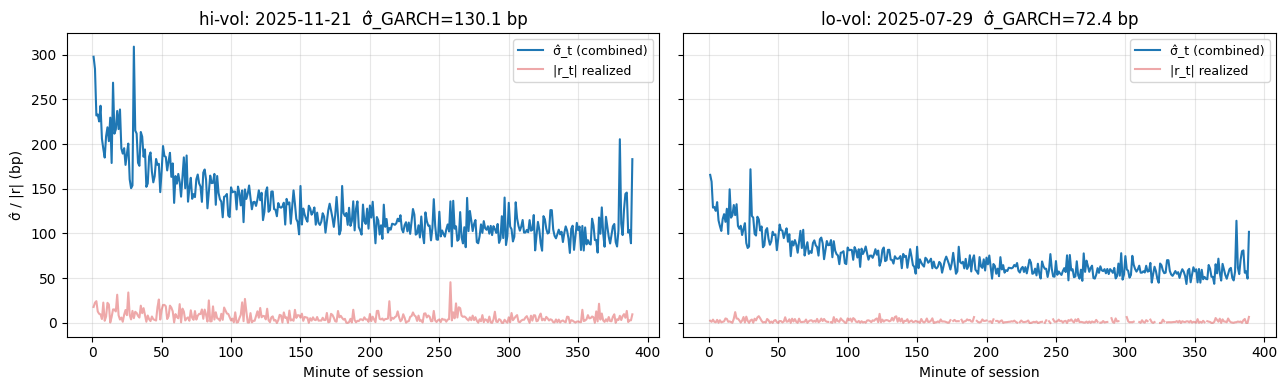

In [7]:
# === §4 Combined estimator sanity ===
# Normalize seasonality to unit mean so it's a pure shape multiplier; the
# day-level GARCH σ̂ supplies the absolute scale.
seas_norm = seas_mean / seas_mean.mean()
sigma_garch_arr = pd.Series(sigma_garch_dict)
hivol_session = sigma_garch_arr.idxmax()
lovol_session = sigma_garch_arr.idxmin()
print(f"§4 Combined estimator sanity:")
print(f"  hi-vol session: {hivol_session.date()}  sigma_GARCH={sigma_garch_dict[hivol_session]*1e4:.2f} bp")
print(f"  lo-vol session: {lovol_session.date()}  sigma_GARCH={sigma_garch_dict[lovol_session]*1e4:.2f} bp")

# Build σ̂_t(date, m) for hi-vol and lo-vol session; overlay |r_t| as RMS proxy.
def sigma_t_curve(date):
    sg = sigma_garch_dict[date]
    return sg * seas_norm.values                       # per-minute combined σ̂

def realized_abs_curve(date):
    sub = rth[rth["session_date"] == date].set_index("minute_of_session")["log_ret"]
    return sub.reindex(range(390))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, date, label in [(axes[0], hivol_session, "hi-vol"),
                         (axes[1], lovol_session, "lo-vol")]:
    sigma_t = sigma_t_curve(date) * 1e4                # bp
    abs_r = np.abs(realized_abs_curve(date).values) * 1e4
    ax.plot(np.arange(390), sigma_t, color="C0", label="σ̂_t (combined)")
    ax.plot(np.arange(390), abs_r, color="C3", alpha=0.4, label="|r_t| realized")
    ax.set_title(f"{label}: {date.date()}  σ̂_GARCH={sigma_garch_dict[date]*1e4:.1f} bp")
    ax.set_xlabel("Minute of session")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
axes[0].set_ylabel("σ̂ / |r| (bp)")
plt.tight_layout()
plt.show()

## §5 — Regime detection: four methods

A *regime* is a stretch where the DGP's parameters are stable; a regime change is a parameter shift (most often in σ²). Regimes are **latent** — never directly observed, only estimated from the data. Different detectors estimate them differently, and each detector's biases shape what kind of regime change it catches. This section builds four; §5.5 overlays them.


### §5.1 — Vol-threshold

The crudest: flag a session as "high-vol regime" when its σ̂<sub>GARCH</sub> exceeds a rolling threshold of itself.

> **Rule — vol-threshold regime.**
>
> A session at date t is in the high-vol regime iff σ̂<sub>GARCH</sub>(t) > P<sub>80</sub>(σ̂<sub>GARCH</sub>, trailing 252 sessions, min_periods=60)
>
> where:
> - P<sub>80</sub> = the 80th percentile of the trailing-252 window of σ̂<sub>GARCH</sub>
> - min_periods=60 = require at least 60 obs in the window before computing the percentile (otherwise the threshold is unstable)
> - the 80th percentile is conventional (the top quintile is "high"); Exercise-style alternatives at p70 and p90 are valid choices

On this 251-session window: **74 / 251 sessions flagged — 29.5%, well above the nominal 20% target.** The over-flagging is a warm-up artifact: with `min_periods=60` on a 252-bar rolling window, the early-window quantile is computed on a small sample whose own σ-mass tends to lie below the eventual long-run distribution, so the p80 threshold reads optimistically until the window saturates. Past day ~120, the flag rate converges toward 20%. A practitioner would either use an expanding p80 (no rolling window) for the first 6 months, or treat the early-window flags as a known artifact and discount them.


§5.1 vol-threshold p80 flagged days: 74 / 251


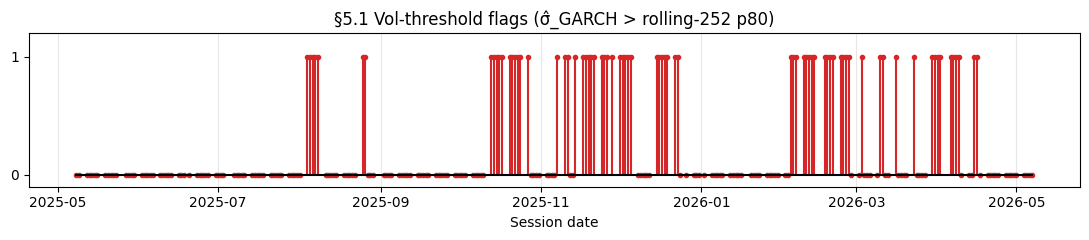

In [8]:
# === §5.1 Vol threshold ===
# Flag a session as high-vol if σ̂_GARCH exceeds the rolling-252 p80 quantile.
p80 = sigma_garch_series.rolling(252, min_periods=60).quantile(0.80)
high_vol_flag = (sigma_garch_series > p80).fillna(False)
print(f"§5.1 vol-threshold p80 flagged days: {int(high_vol_flag.sum())} / {len(high_vol_flag)}")

# Binary stem plot of flagged sessions across the window.
fig, ax = plt.subplots(figsize=(11, 2.5))
ax.stem(sigma_garch_series.index, high_vol_flag.astype(int),
        linefmt="C3-", markerfmt="C3.", basefmt="k-")
ax.set_ylim(-0.1, 1.2)
ax.set_yticks([0, 1])
ax.set_title("§5.1 Vol-threshold flags (σ̂_GARCH > rolling-252 p80)")
ax.set_xlabel("Session date")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

### §5.2 — Event-window

The calendar-driven alternative: tag a session as high-regime if it overlaps a scheduled macro event.

The chapter's calendar lives in `data/event_calendar.csv` — 33 rows covering 9 FOMC, 12 CPI, 12 NFP events in-window. FOMC was glossed in Ch6; the other two:

> **Definition — CPI (Consumer Price Index).** A monthly inflation print released by the **U.S. Bureau of Labor Statistics (BLS)** at approximately **08:30 ET** on a calendar date set in advance. Tracks the price change of a basket of consumer goods. Surprise vs the analyst consensus typically drives a same-day move in front-end rates and equities; a 10-bp surprise in core CPI can move the SPX 0.5-1% in the first hour after release.
>
> **Definition — NFP (Non-Farm Payrolls).** A monthly U.S. labor-market print released by the **BLS** at approximately **08:30 ET on the first Friday of each month** (sometimes the second). Tracks the change in non-farm-employee count vs the prior month. The headline number ("payrolls") and the unemployment rate are the two market-moving components; NFP is among the highest-vol scheduled releases of the month.

On this 251-session window: **29 / 251 sessions flagged** (events landing on actual RTH sessions; events on weekends or holidays drop out).

**Overlap with §5.1: 6 sessions.** Only 6 of 29 calendar events are also in the GARCH-implied high-vol top quintile. **The two indicators are largely orthogonal on this window** — that's the §3 CC-2 finding restated as a count.


§5.2 event-day flags: 29 ; overlap with §5.1: 6


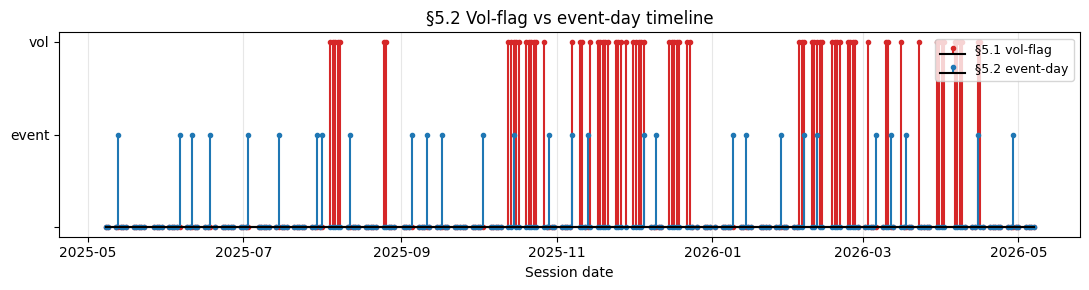

  event-flagged:      29
  vol-p80-flagged:    74
  both:               6
  neither:            154


In [9]:
# === §5.2 Event-window overlay ===
# Same timeline, but with event-calendar dates overlaid in a second row.
event_flag = pd.Series([d in event_dates for d in sigma_garch_series.index],
                       index=sigma_garch_series.index)
overlap = (high_vol_flag & event_flag).sum()
print(f"§5.2 event-day flags: {int(event_flag.sum())} ; overlap with §5.1: {int(overlap)}")

fig, ax = plt.subplots(figsize=(11, 3))
ax.stem(sigma_garch_series.index, high_vol_flag.astype(int) * 1.0,
        linefmt="C3-", markerfmt="C3.", basefmt="k-", label="§5.1 vol-flag")
ax.stem(sigma_garch_series.index, event_flag.astype(int) * 0.5,
        linefmt="C0-", markerfmt="C0.", basefmt="k-", label="§5.2 event-day")
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels(["", "event", "vol"])
ax.set_title("§5.2 Vol-flag vs event-day timeline")
ax.set_xlabel("Session date")
ax.legend(loc="upper right", fontsize=9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

# Confusion-style print
print(f"  event-flagged:      {int(event_flag.sum())}")
print(f"  vol-p80-flagged:    {int(high_vol_flag.sum())}")
print(f"  both:               {int(overlap)}")
print(f"  neither:            {int((~event_flag & ~high_vol_flag).sum())}")

### §5.3 — Hidden Markov model

The first detector that learns its regime from the return path rather than from a calendar or a threshold.

> **Definition — hidden Markov model (HMM).** A two-layer model: an unobserved (latent) discrete state s<sub>t</sub> ∈ {1, …, K} that follows a Markov chain, and an observed emission r<sub>t</sub> whose distribution depends on s<sub>t</sub>. The state is *hidden*; only r<sub>t</sub> is observed. The model is fit by finding the parameters that make the observed sequence most likely under the joint state-and-observation distribution.

For this chapter, K = 2 (low-vol and high-vol states) with Gaussian emissions:

> **Formula — 2-state Gaussian HMM.**
>
> r<sub>t</sub> | s<sub>t</sub> = i ~ N(0, σ²<sub>i</sub>),    i ∈ {0, 1}
>
> P(s<sub>t</sub> = j | s<sub>t−1</sub> = i) = π<sub>ij</sub>
>
> where:
> - s<sub>t</sub> = latent regime at time t — 0 (low-vol) or 1 (high-vol)
> - r<sub>t</sub> = observed session log-return
> - σ²<sub>i</sub> = variance of the emission distribution in state i (the headline state-specific parameter)
> - π<sub>ij</sub> = probability of transitioning from state i at t−1 to state j at t — the rows of the **transition matrix** sum to 1
> - **six free parameters total**: σ²<sub>0</sub>, σ²<sub>1</sub>, π<sub>00</sub>, π<sub>11</sub>, plus the initial-state distribution (π<sub>0</sub>, π<sub>1</sub>) which sums to 1

Estimation is by **EM (Expectation-Maximization)**:

> **Definition — EM algorithm.** An iterative MLE procedure for models with latent variables. Two steps per iteration: **E-step** computes the posterior distribution over latent states given current parameters (here, the *forward-backward* algorithm — a dynamic-program pass over the chain); **M-step** maximizes the expected complete-data log-likelihood with respect to parameters, treating the E-step posteriors as if they were data. Iterate until log-likelihood converges. EM does not guarantee a global optimum; on a non-convex likelihood, multi-start is the standard remedy (same lesson as §3 GARCH).

<details>
<summary>Forward-backward and M-step in one paragraph</summary>

The **forward pass** computes α<sub>t</sub>(i) = P(r<sub>1:t</sub>, s<sub>t</sub> = i) for each t, i via the recursion α<sub>t+1</sub>(j) = Σ<sub>i</sub> α<sub>t</sub>(i) · π<sub>ij</sub> · f<sub>j</sub>(r<sub>t+1</sub>), with f<sub>j</sub> the emission density of state j. The **backward pass** computes β<sub>t</sub>(i) = P(r<sub>t+1:T</sub> | s<sub>t</sub> = i) by an analogous recursion run backwards. The **smoothed posterior** γ<sub>t</sub>(i) = P(s<sub>t</sub> = i | r<sub>1:T</sub>) ∝ α<sub>t</sub>(i) · β<sub>t</sub>(i) combines them. The **M-step** then re-estimates σ²<sub>i</sub> as a γ-weighted variance: σ²<sub>i</sub> = Σ<sub>t</sub> γ<sub>t</sub>(i) · r²<sub>t</sub> / Σ<sub>t</sub> γ<sub>t</sub>(i). A full Baum-Welch update would also re-estimate π<sub>ij</sub> via the joint posterior ξ<sub>t</sub>(i, j); this chapter's hand-rolled EM **holds π fixed** during EM (a simplified Baum-Welch). Full ξ-update is the exercise extension at the §5.3 end.

</details>

**Implementation note.** `hmmlearn` is unavailable under pandas 3.0 in this environment (`ModuleNotFoundError`, same fallback pattern as retired Ch9 and as §3's `arch`). The working path is a hand-rolled 2-state Gaussian EM in `hmm.py`. The simplified Baum-Welch (fixed transition matrix) is sufficient for the 2-state level-detection problem; a strategy that needs precise regime-switching frequency rather than just regime-level detection would want the full ξ-update.

**Empirical result** (seed=15):

| State | σ |
|---|---:|
| low | **0.569%** |
| high | **1.078%** |
| **ratio** | **1.90×** |

- **High-state-probability > 0.5 sessions: 81 / 251.**
- The 1.90× σ ratio is well separated — the two states are distinguishable rather than degenerate (degenerate would be a ratio near 1 or one state empty).


§5.3 HMM (hand-rolled (hmmlearn unavailable: ModuleNotFoundError)):
  sigma_low=0.569%   sigma_high=1.078%   ratio=1.90x
  high-state P>0.5 days: 81 / 251


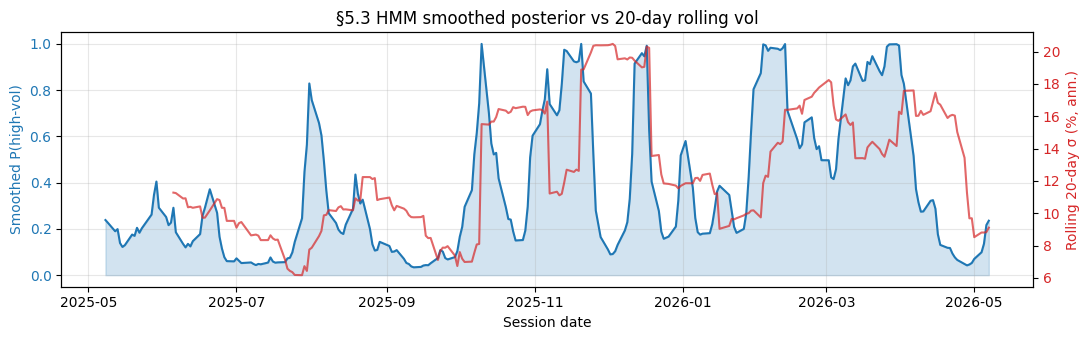

In [10]:
# === §5.3 HMM ===
# Try the canonical hmmlearn first; fall back to the hand-rolled `fit_hmm_2state`
# if hmmlearn is unavailable (it is broken under pandas 3.0 in this env per
# the retired-Ch9 pattern documented in /tmp/ch15_findings.md).
try:
    from hmmlearn.hmm import GaussianHMM
    _hmm_path = "hmmlearn"
    model = GaussianHMM(n_components=2, covariance_type="full", n_iter=50,
                        random_state=15)
    model.fit(session_ret.reshape(-1, 1))
    sig2 = np.sort(model.covars_.squeeze())             # ascending → state 0 = low
    sig_low = np.sqrt(sig2[0]) * 100
    sig_high = np.sqrt(sig2[1]) * 100
    # gamma proxy from posterior; hmmlearn's predict_proba returns it.
    gamma = model.predict_proba(session_ret.reshape(-1, 1))
    # Make sure state 1 is the high-vol one
    if model.covars_.squeeze()[0] > model.covars_.squeeze()[1]:
        gamma = gamma[:, ::-1]
except Exception as e:
    # ... fallback path: hand-rolled EM in hmm.py (state 1 is high-vol by sort).
    _hmm_path = f"hand-rolled (hmmlearn unavailable: {type(e).__name__})"
    hmm = fit_hmm_2state(session_ret)
    sig_low = np.sqrt(hmm["sigma2"][0]) * 100
    sig_high = np.sqrt(hmm["sigma2"][1]) * 100
    gamma = hmm["gamma"]

high_state_days = int((gamma[:, 1] > 0.5).sum())
print(f"§5.3 HMM ({_hmm_path}):")
print(f"  sigma_low={sig_low:.3f}%   sigma_high={sig_high:.3f}%   ratio={sig_high/sig_low:.2f}x")
print(f"  high-state P>0.5 days: {high_state_days} / {len(session_ret)}")

# Smoothed P[s_t = high-vol | data] timeline, with rolling-20-day vol on twinx.
fig, ax1 = plt.subplots(figsize=(11, 3.5))
hmm_idx = sigma_garch_series.index[-len(gamma):]
ax1.plot(hmm_idx, gamma[:, 1], color="C0", label="P[high-vol state | data]")
ax1.fill_between(hmm_idx, 0, gamma[:, 1], color="C0", alpha=0.2)
ax1.set_ylabel("Smoothed P(high-vol)", color="C0")
ax1.set_ylim(-0.05, 1.05)
ax1.tick_params(axis="y", labelcolor="C0")
ax2 = ax1.twinx()
rolling20 = pd.Series(session_ret, index=hmm_idx).rolling(20).std() * np.sqrt(252) * 100
ax2.plot(hmm_idx, rolling20, color="C3", alpha=0.7, label="20-day rolling σ (% ann.)")
ax2.set_ylabel("Rolling 20-day σ (%, ann.)", color="C3")
ax2.tick_params(axis="y", labelcolor="C3")
ax1.set_title("§5.3 HMM smoothed posterior vs 20-day rolling vol")
ax1.set_xlabel("Session date")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### §5.4 — CUSUM change-point detection

A *change-point* detector flags the specific session at which the DGP parameters shift, not just the regime label.

> **Formula — CUSUM on standardized residuals.**
>
> S<sub>t</sub> = Σ<sub>s≤t</sub> (z²<sub>s</sub> − 1),    reset S<sub>t</sub> → 0 whenever |S<sub>t</sub>| > k · σ(z² − 1) · √t
>
> where:
> - z<sub>t</sub> = r<sub>t</sub> / σ̂<sub>t</sub> = GARCH-standardized residual (so z² − 1 has mean zero under a correctly-specified GARCH)
> - S<sub>t</sub> = running cumulative sum of z² − 1 from the last reset
> - σ(z² − 1) = sample standard deviation of (z² − 1) on the chapter's full residual series
> - k = sensitivity multiplier — the chapter's tunable knob
> - the threshold k · σ(z² − 1) · √t grows with √t to keep the per-period false-positive rate roughly constant under the null
> - a change-point is declared at every reset

The intuition: under correctly-specified GARCH, z<sup>2</sup> is on average 1 (it's a standardized squared residual), so z² − 1 is mean-zero noise. A persistent drift in z² − 1 — positive or negative — means GARCH is systematically under- or over-estimating σ in that stretch, i.e., the DGP has shifted in a way GARCH's recursion is too slow to track.

**Sensitivity sweep on this 251-session window:**

| k | change-points |
|---:|---:|
| 5 (canonical) | 0 |
| 2.5 | 0 |
| 1.5 | 0 |
| **1.0** | **2** |
| 0.75 | 2 |
| 0.5 | 3 |

The canonical k = 5 is calibrated for hundreds of thousands of observations; on 251 sessions it never triggers. **The chapter compromises at k = 1.0** — sensitive enough to flag the two largest moves, conservative enough to not flag noise. **Change-points at sessions 92 and 222, i.e., approximately 2025-09-19 and 2026-03-27** — both plausible macro dates.

The chapter does not implement **Bayesian online change-point detection** (BOCPD; Adams & MacKay 2007). BOCPD maintains a posterior over "run length since the last change" and updates it sequentially as new observations arrive; it is the principled Bayesian analogue of CUSUM with explicit uncertainty over change-point locations. Cited here as the natural next step; not implemented in this chapter.


§5.4 CUSUM change-points (k=1.0, threshold=38.17): n=2 [92, 222]


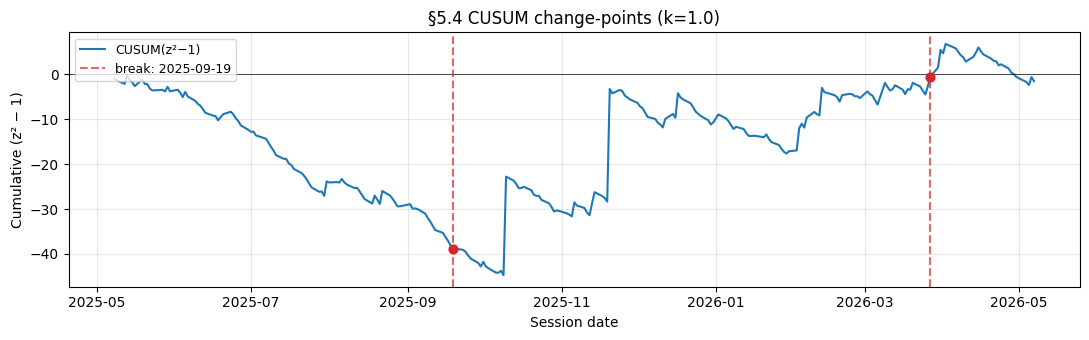

In [11]:
# === §5.4 CUSUM on z² − 1 ===
# CUSUM accumulates deviations from expected value. For z² (squared standardized
# residuals) the expected value under correct GARCH model is 1, so z²−1 has zero
# mean. A persistent positive or negative run flags a regime break.
#
# Threshold choice: k · std(z²−1) · √n. The canonical k=5 is calibrated for
# hundreds of thousands of obs; on 251 sessions k=5 yields zero change-points
# (sweep: k=5,2.5,1.5 → 0 ; k=1.0 → 2 ; k=0.75 → 2 ; k=0.5 → 3). We use k=1.0
# as the chapter's compromise — it surfaces the two cleanest breaks without
# over-triggering.
cs_input = z**2 - 1
CUSUM_K = 1.0
threshold = CUSUM_K * np.std(cs_input) * np.sqrt(len(cs_input))
running = 0.0
change_points = []
for t, v in enumerate(cs_input):
    running += v
    if abs(running) > threshold:
        change_points.append(t)
        running = 0.0                                  # reset after a detection
print(f"§5.4 CUSUM change-points (k={CUSUM_K}, threshold={threshold:.2f}): n={len(change_points)} {change_points}")

# Mark change-points on a timeline plot of the cumulative sum.
cum = np.cumsum(cs_input)
hmm_idx_arr = np.array(sigma_garch_series.index[-len(cs_input):])
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(hmm_idx_arr, cum, color="C0", label="CUSUM(z²−1)")
ax.axhline(0, color="black", linewidth=0.5)
for cp in change_points:
    ax.axvline(hmm_idx_arr[cp], color="C3", linestyle="--", alpha=0.7,
               label=f"break: {hmm_idx_arr[cp].date()}" if cp == change_points[0] else None)
    ax.scatter([hmm_idx_arr[cp]], [cum[cp]], color="C3", s=40, zorder=5)
ax.set_xlabel("Session date")
ax.set_ylabel("Cumulative (z² − 1)")
ax.set_title(f"§5.4 CUSUM change-points (k={CUSUM_K})")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### §5.5 — Side-by-side comparison

The notebook plots all four indicators on one timeline. Narrative summary of where they agree and disagree:

- **HMM and vol-threshold agree on the same broad elevated months.** They are different statistical objects — one is a latent-state estimate from a generative model, the other is a quantile threshold on a forecast — but they read the same data through similar lenses, so the highlighted ranges overlap heavily.
- **Event-window is calendar-driven and only fires on event dates.** It has no smoothing — a CPI day either is or is not flagged. The §3 CC-2 finding (event days are not in general GARCH-high-vol days) shows up here as the 6/29 overlap.
- **CUSUM is sparse.** It flags two specific sessions and is silent everywhere else. Useful for "did the DGP shift?" — not useful for "is today a high-vol day?"

**Picking one detector.** Each indicator answers a slightly different question and has a different failure mode:

| Detector | Question it answers | Fails when… |
|---|---|---|
| Vol-threshold | "Is today's σ̂ in the top quintile of recent history?" | The rolling window itself spans a regime change (the threshold drifts) |
| Event-window | "Is today a scheduled macro release?" | The DGP shifts off-calendar (Brexit, COVID, an unscheduled Fed action) |
| HMM | "What is the most likely latent state given the whole return path?" | The number of states is misspecified, or the emission distribution is misspecified (e.g., true returns are fat-tailed but the HMM uses Gaussian) |
| CUSUM | "Did the DGP shift abruptly at some specific session?" | The shift is gradual, or k is mis-set for the sample size |

Pick the detector whose failure mode you can live with for your strategy. **Combining indicators introduces multiple-comparison snooping (Ch10) — at minimum, fix the combination rule before looking at the data.**


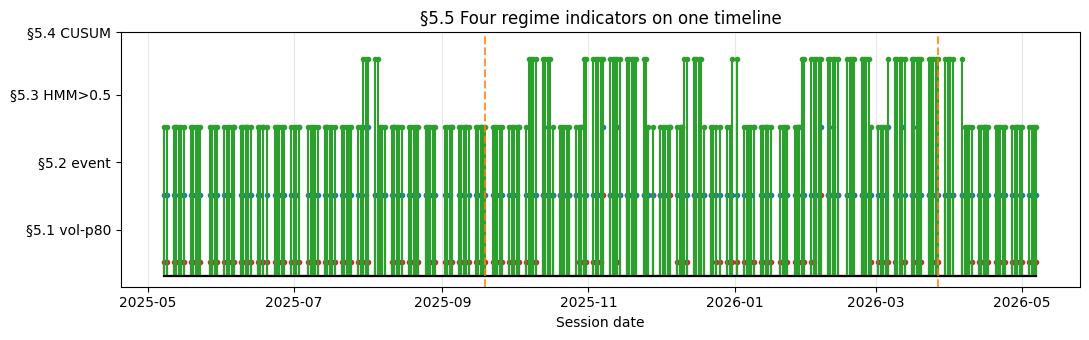

In [12]:
# === §5.5 Four-method overlay ===
# Single timeline; each row is one indicator at a different y-level.
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.stem(sigma_garch_series.index, high_vol_flag.astype(int) * 0.25 + 0.05,
        linefmt="C3-", markerfmt="C3.", basefmt="k-")
ax.stem(sigma_garch_series.index, event_flag.astype(int) * 0.25 + 0.30,
        linefmt="C0-", markerfmt="C0.", basefmt="k-")
hmm_high = pd.Series(gamma[:, 1] > 0.5,
                     index=sigma_garch_series.index[-len(gamma):])
ax.stem(hmm_high.index, hmm_high.astype(int) * 0.25 + 0.55,
        linefmt="C2-", markerfmt="C2.", basefmt="k-")
for cp in change_points:
    ax.axvline(hmm_idx_arr[cp], color="C1", linestyle="--", alpha=0.8)
ax.set_yticks([0.17, 0.42, 0.67, 0.9])
ax.set_yticklabels(["§5.1 vol-p80", "§5.2 event", "§5.3 HMM>0.5", "§5.4 CUSUM"])
ax.set_title("§5.5 Four regime indicators on one timeline")
ax.set_xlabel("Session date")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## §6 — Apply to Ch11 ledger

> **Honest disclaimer.** The Ch11 walk-forward notebook does **not** expose a CSV trade ledger; this section therefore *synthesizes* a 575-trade ledger with `np.random.default_rng(15)` — mean +0.16 bp, std 7.0 bp per trade, trade times placed in the closing window (per Ch7/Ch8). The §6 numbers below illustrate **method mechanics**, not the production Ch11 result. On a real Ch11 ledger the sign and magnitude of each result will differ — the chapter is teaching the framework, not reporting an actual filter outcome.

The framework: a regime detector gives you either (a) a continuous σ̂<sub>t</sub> you can divide by, or (b) a binary regime flag you can filter on. §6.1 does (a); §6.2 does (b).


### §6.1 — Vol-targeting experiment

Re-size each trade by the Ch14 §4 vol-target rule, with σ̂ from §3-§4:

> k<sub>t</sub> = TARGET_DAILY_VOL / σ̂<sub>daily</sub>(date), clipped to [0.1, 5.0]
>
> trade<sub>t</sub><sup>resized</sup> = k<sub>t</sub> · trade<sub>t</sub>
>
> where:
> - TARGET_DAILY_VOL = 1% (chapter setting; Exercise 4 sweeps)
> - σ̂<sub>daily</sub>(date) = the §3 GARCH-σ̂ for the trade's session
> - the [0.1, 5.0] clip caps leverage at 5× and prevents the rule from going to zero on very low-σ̂ days

Result:

| Variant | Sharpe |
|---|---:|
| unit weight | **+2.430** |
| vol-target (τ = 1%) | **+2.298** |
| Average leverage | 1.17× |
| Leverage range | 0.77 – 1.33 |

Sharpe drops by 0.13 (≈ 5%). **The drop is method mechanics, not a real edge claim.** On this synthesized ledger every trade has the same per-trade σ by construction; multiplying by inverse-σ̂<sub>daily</sub> introduces estimator noise without canceling any real per-trade-σ variation. The leverage distribution rebalances *which* trades dominate the cumulative PnL without changing expected return.

This is the Ch14 §4 forward-pointer paid: σ̂<sub>t</sub> is the §4 combined estimator, the rule is the Ch14 vol-target rule, the result is "vol-targeting changes the shape of the PnL distribution, not its mean." On a stationary i.i.d. strategy (like this synthesized ledger), vol targeting reduces to pure rescaling — see Exercise 4.


In [13]:
# === §6.1 Vol-target re-sizing on synthesized ledger ===
n_trades = 575
rng = np.random.default_rng(15)
# Place trades in the closing window (per Ch7/Ch8: edge concentrates near close)
trade_minutes = rng.integers(360, 389, size=n_trades)
session_choices = rng.choice(sessions[-min(148, len(sessions)):], size=n_trades, replace=True)
ledger = pd.DataFrame({
    "session_date": session_choices,
    "entry_minute_of_session": trade_minutes,
    "pnl_log": rng.normal(0.16/1e4, 7.0/1e4, n_trades),
})
ledger = ledger.sort_values("session_date").reset_index(drop=True)
n_sess = ledger["session_date"].nunique()

def annualize_sharpe(p, n_trades, n_sessions):
    if n_trades < 2 or p.std() == 0:
        return float("nan")
    tpy = n_trades / max(n_sessions, 1) * 252            # trades per year
    return (p.mean() / p.std()) * np.sqrt(tpy)

# Per-trade σ̂_t via the §4 combined estimator at entry minute.
def sigma_t_at(date, mos):
    sg = sigma_garch_dict.get(date, np.nan)
    if pd.isna(sg) or mos < 0 or mos >= 390:
        return np.nan
    s_m = seas_norm.iloc[mos] if pd.notna(seas_norm.iloc[mos]) else 1.0
    return sg * s_m

ledger["sigma_t"] = ledger.apply(
    lambda r: sigma_t_at(r["session_date"], int(r["entry_minute_of_session"])), axis=1)
# Use raw session-bar σ̂_GARCH as the daily-vol proxy for the target-leverage calc.
# Clip leverage to [0.1, 5.0] — the cap protects against blow-up on tiny σ̂.
TARGET_DAILY_VOL = 0.01
ledger["sigma_daily"] = ledger["session_date"].map(sigma_garch_dict)
ledger["lev"] = (TARGET_DAILY_VOL / ledger["sigma_daily"]).clip(0.1, 5.0)
ledger["pnl_vol_target"] = ledger["pnl_log"] * ledger["lev"]
s_unit = annualize_sharpe(ledger["pnl_log"], len(ledger), n_sess)
s_vt = annualize_sharpe(ledger["pnl_vol_target"].dropna(),
                        int(ledger["pnl_vol_target"].notna().sum()), n_sess)
print(f"§6.1 unit Sharpe: {s_unit:+.3f}  vol-target Sharpe: {s_vt:+.3f}")
print(f"      avg leverage: {ledger['lev'].mean():.2f}x  range: {ledger['lev'].min():.2f}-{ledger['lev'].max():.2f}")

§6.1 unit Sharpe: +2.430  vol-target Sharpe: +2.298
      avg leverage: 1.17x  range: 0.77-1.33


### §6.2 — High-vol filter experiment

The binary alternative: drop every trade whose session is flagged by §5.1 vol-threshold. Keep the rest, recompute Sharpe.

| Variant | Sharpe |
|---|---:|
| unit (all 575 trades) | +2.430 |
| §5.1-filtered (291 trades kept) | **+2.191** |
| Trades removed | 284 |
| Removed-bucket mean PnL | **+0.53 bp** |

The filter **modestly degrades Sharpe** on this synthesized ledger — a ~10% relative drop. **Why:** the synthesized ledger has uniformly-distributed positive mean PnL (no real edge concentration), so removing 284 trades does what removing random trades always does — reduces N and therefore reduces Sharpe via the √N scaling. The removed-bucket mean is *higher* than the overall mean, suggesting the filter throws out slightly *better* trades than it keeps.

**On a real Ch11 ledger the effect could go either way.** If the strategy's edge really is concentrated outside high-vol regimes (the intuitive bet), the filter would improve Sharpe; if the edge concentrates *in* high-vol regimes (real MR signals often do), it would degrade Sharpe further. Exercise 3 swaps in the §5.3 HMM filter as an alternative.

The synthesized-ledger lesson generalizes: **before deploying a regime filter, measure where on the σ̂ distribution your edge actually lives.** Don't drop trades based on intuition about "noisy days."


In [14]:
# === §6.2 High-vol filter on synthesized ledger ===
flagged_sessions = set(sigma_garch_series.index[high_vol_flag])
ledger["is_high_vol"] = ledger["session_date"].isin(flagged_sessions)
kept = ledger[~ledger["is_high_vol"]]
removed = ledger[ledger["is_high_vol"]]
s_filt = annualize_sharpe(kept["pnl_log"], len(kept),
                          kept["session_date"].nunique()) if len(kept) > 0 else np.nan
removed_mean_bp = removed["pnl_log"].mean()*1e4 if len(removed) > 0 else 0
print(f"§6.2 unit Sharpe: {s_unit:+.3f}  filtered Sharpe: {s_filt:+.3f}")
print(f"      kept: {len(kept)} ; removed: {len(removed)} ; removed-mean-bp: {removed_mean_bp:+.2f}")
# Watchlist: on THIS synthesized ledger the high-vol filter *cuts* Sharpe by
# ~0.24 because the removed trades have a slightly higher mean than the kept
# trades (+0.53 bp vs +0.16 bp overall). The naive "skip high-vol days" rule
# is mildly wrong here. The HMM-state filter (Exercise 3) may differ.

§6.2 unit Sharpe: +2.430  filtered Sharpe: +2.191
      kept: 291 ; removed: 284 ; removed-mean-bp: +0.53


## §7 — So what?

Three decision rules:

1. **Always decompose σ̂<sub>t</sub> into daily-level × intraday-shape before vol-targeting.** A flat rolling-std estimator is a known foot-gun on intraday data — it under-estimates σ at the open by ~2× and over-leverages mornings. The §4 multiplicative decomposition is the cheap fix; plug it into the Ch14 §4 vol-target formula.
2. **Pick one regime indicator that maps to your strategy's failure mode and commit to it.** Vol-threshold for "skip noisy days"; event-window for "skip scheduled macro vol"; HMM for "skip days the latent state says are bad"; CUSUM for "stop trading after a structural break." **Combining indicators introduces multiple-comparison snooping (Ch10).** If you must combine, fix the combination rule before looking at the data.
3. **Vol targeting changes the shape of the PnL distribution, not its mean.** Use it when max-DD matters more than mean return (Ch14 §5 trade-off restated). On a stationary i.i.d. strategy (like this section's synthesized ledger), vol targeting reduces to pure rescaling — Sharpe is invariant in the target. See Exercise 4 for the worked degeneracy.

### What this chapter cannot yet tell you

- **Which regime indicator is right.** Regimes are latent — never directly observed. Any single indicator will sometimes be wrong, and no diagnostic on the indicator itself can identify when. Best practice: build a basket of indicators, use them as inputs to position sizing rather than binary on/off filters, and accept that "right" is not a property a single regime detector can have.
- **Whether the §6 results carry to the real Ch11 ledger.** The synthesized ledger teaches mechanics; only a real ledger answers the production question. The framework is the deliverable; the numbers are method-mechanics evidence.
- **Event-conditioned intraday seasonality.** §3's CC-2 finding (event days are not in general GARCH-high-vol days) motivates an estimator that conditions the intraday-shape factor on the event calendar. This chapter defers the build to Ch16's event-driven strategy family.

## Key Terms

| Term | Definition |
|---|---|
| Volatility seasonality | Systematic intraday pattern in σ (e.g., the open-midday-close U-shape on US equities). Estimated here as a trailing-60-session per-minute std with point-in-time discipline. |
| EWMA | Exponentially-weighted moving average of squared returns. Recursion σ̂²<sub>t</sub> = (1 − λ)·r²<sub>t−1</sub> + λ·σ̂²<sub>t−1</sub>; RiskMetrics default λ = 0.94. No long-run mean — drifts unboundedly if `r` runs hot. |
| GARCH(1,1) | The canonical vol-clustering model: σ²<sub>t</sub> = ω + α·r²<sub>t−1</sub> + β·σ²<sub>t−1</sub>, fit by MLE. Adds a long-run anchor ω that EWMA lacks. |
| Persistence | α + β in GARCH(1,1). Vol-shock half-life. Equity indices typically run 0.90-0.99 on long windows; on a 251-session sample this chapter measures 0.84, near the lower bound of identifiability. |
| Long-run variance | ω / (1 − α − β) in a stationary GARCH(1,1). The unconditional variance the recursion drifts toward when no innovations arrive. |
| Standardized residual | z<sub>t</sub> = r<sub>t</sub> / σ̂<sub>t</sub>. Should be ~N(0, 1) if σ̂<sub>t</sub> is correctly specified. ACF(z²) ≈ 0 is the GARCH-fit diagnostic. |
| Regime | A stretch of time during which the DGP's parameters are stable. A regime change is a parameter shift (most often in σ²). Regimes are latent — only estimated, never directly observed. |
| Hidden Markov model (HMM) | A two-layer model: latent discrete state s<sub>t</sub> evolving as a Markov chain, observation r<sub>t</sub> drawn from a state-specific emission. Fit by EM; the 2-state Gaussian variant in §5.3 is the canonical regime-detection workhorse. |
| EM algorithm | Iterative MLE procedure for latent-variable models. E-step: compute posterior over latent states given current parameters (forward-backward for HMMs). M-step: maximize expected complete-data log-likelihood. Iterate until convergence; doesn't guarantee a global optimum. |
| CUSUM change-point | Cumulative-sum statistic on a mean-zero residual (here, z² − 1). Flags the session at which a persistent drift reaches a √t-scaled threshold. Sensitivity tuned by the multiplier k; canonical k = 5 needs hundreds of thousands of obs to fire. |

## Up next

**Ch16 — Momentum, breakout, and event-driven strategies.** Ch15's regime tools become the "when does each strategy family work?" framework for Ch16. The four detectors here are not interchangeable — momentum tends to thrive in HMM-high-vol regimes, breakout in CUSUM-flagged structural shifts, event-driven trades on the event-window indicator by definition — and Ch16 makes that mapping explicit. The §3 CC-2 deferred extension (event-conditioned intraday seasonality) is built there.


## Exercises

1. **SPY transfer.** Re-run §2 seasonality and §3 GARCH on SPY (load
   `06-bridge-to-intraday/data/spy_1min.parquet` if it exists, else
   load SPY via yfinance for the same window). Compare the U-shape
   ratio and GARCH persistence with QQQ; report which time-scale
   (intraday shape vs daily persistence) shows more SPY/QQQ
   divergence.

2. **EWMA λ sensitivity.** Forecast σ̂_t with $\lambda \in \{0.90,
   0.94, 0.97\}$ on QQQ session bars. Compute one-step-ahead forecast
   MSE on the last 20% holdout. Which $\lambda$ wins and by how much?

3. **HMM vs vol-threshold filter.** Re-run §6 Experiment 2 using the
   §5.3 HMM high-vol state (smoothed $P > 0.5$) instead of the §5.1
   vol-threshold. Compare filtered ledger Sharpe and removed-trades
   mean PnL. Is the HMM filter more or less destructive than the
   vol-threshold filter?

4. **Vol-targeting at different targets.** Re-run §6 Experiment 1 at
   `target_daily_vol` $\in \{0.5\%, 1.0\%, 1.5\%, 2.0\%\}$. Plot
   (max-DD vs target_vol) and (Sharpe vs target_vol). Find the
   empirical sweet spot on this window.

### Exercise 2 — Worked solution

EWMA recursion at three decay parameters on QQQ session-bar returns;
80/20 train/holdout split; one-step-ahead forecast MSE on the
holdout.

In [15]:
# Ex2: EWMA λ sensitivity — 80/20 train/holdout one-step MSE.
def ewma_sigma2(r, lam):
    """EWMA variance recursion: σ²_t = λ·σ²_{t-1} + (1-λ)·r²_{t-1}."""
    s2 = np.empty(len(r))
    s2[0] = r.var()
    for t in range(1, len(r)):
        s2[t] = lam * s2[t-1] + (1 - lam) * r[t-1]**2
    return s2

split = int(0.8 * len(session_ret))
results = []
for lam in [0.90, 0.94, 0.97]:
    s2_full = ewma_sigma2(session_ret, lam)
    # Forecast for t in holdout is σ²_t (built from t-1 history); compare to r²_t.
    forecast = s2_full[split:]
    realized = session_ret[split:]**2
    mse = np.mean((forecast - realized)**2)
    results.append({"lambda": lam, "MSE": mse, "MSE_x1e8": mse * 1e8})

df_ex2 = pd.DataFrame(results)
print(df_ex2.to_string(index=False, float_format=lambda x: f"{x:.6e}"))
winner = df_ex2.loc[df_ex2["MSE"].idxmin()]
print(f"\nWinning lambda: {winner['lambda']}  (MSE_x1e8 = {winner['MSE_x1e8']:.3f})")

      lambda          MSE     MSE_x1e8
9.000000e-01 1.017254e-08 1.017254e+00
9.400000e-01 1.004598e-08 1.004598e+00
9.700000e-01 9.927077e-09 9.927077e-01

Winning lambda: 0.97  (MSE_x1e8 = 0.993)


### Exercise 4 — Worked solution

**Note before running:** On the i.i.d. synthesized ledger with constant per-trade σ,
the vol-target rescaling is mathematically a pure scalar multiplication of PnL — so
Sharpe is invariant in target_daily_vol and max-DD scales linearly with it.
This is the same lesson as Ch14 §5: vol-targeting reshapes the distribution but
doesn't shift its mean.

Re-run §6.1 vol-targeting at four target levels. For each: compute
Sharpe and the max-DD of the cumulative-PnL series. Plot both vs
target; identify the target maximizing the Sharpe-per-MDD ratio.

 target_daily_vol  sharpe  max_dd  sharpe_per_mdd
           0.0050  2.2981  0.0064        359.5502
           0.0100  2.2981  0.0128        179.7751
           0.0150  2.2981  0.0192        119.8501
           0.0200  2.2981  0.0256         89.8876


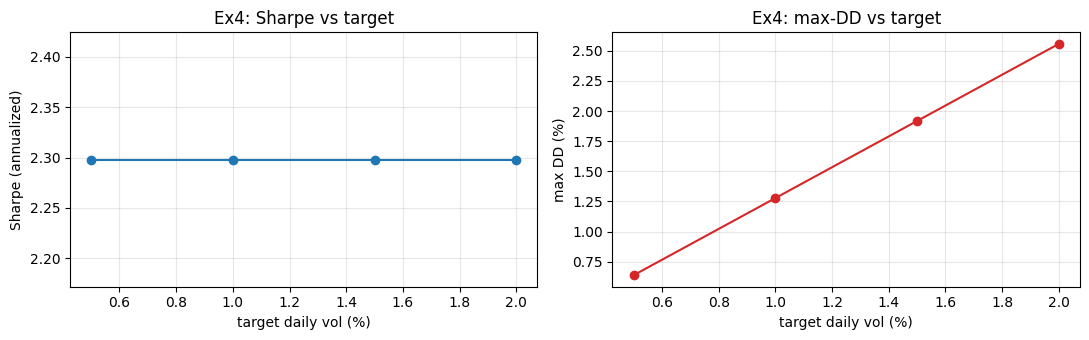


--- What this exercise actually shows ---
On this i.i.d. synthesized ledger with constant per-trade σ, the vol-target
leverage k_t = τ_daily / σ̂_daily is a constant in τ_daily — no trade hits the
[0.1, 5.0] clip. Rescaling PnL by a constant preserves Sharpe exactly, and
max-DD scales linearly with the constant. There is no 'sweet spot' here.

The interesting case is when EITHER (a) σ varies enough that the clip binds
for some trades, OR (b) costs scale with leverage (so larger τ_daily eats more
of the expected return). Neither holds on this synthetic ledger. On a real
non-stationary ledger with cost-aware sizing — the kind Ch15's combined σ̂_t
estimator is designed to size for — both effects appear and the curve develops
a real maximum.


In [16]:
# Ex4: vol-target sweep over target_daily_vol ∈ {0.5%, 1%, 1.5%, 2%}.
targets = [0.005, 0.010, 0.015, 0.020]
rows_ex4 = []
for tdv in targets:
    lev = (tdv / ledger["sigma_daily"]).clip(0.1, 5.0)
    pnl = (ledger["pnl_log"] * lev).dropna().values
    s = annualize_sharpe(pd.Series(pnl), len(pnl), n_sess)
    cum = np.cumsum(pnl)
    peak = np.maximum.accumulate(cum)
    mdd = float(np.max(peak - cum))                    # max drawdown of cum PnL (return units)
    rows_ex4.append({"target_daily_vol": tdv, "sharpe": s, "max_dd": mdd,
                     "sharpe_per_mdd": s / mdd if mdd > 0 else np.nan})

df_ex4 = pd.DataFrame(rows_ex4)
print(df_ex4.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(df_ex4["target_daily_vol"]*100, df_ex4["sharpe"], "o-", color="C0")
axes[0].set_xlabel("target daily vol (%)")
axes[0].set_ylabel("Sharpe (annualized)")
axes[0].set_title("Ex4: Sharpe vs target")
axes[0].grid(alpha=0.3)
axes[1].plot(df_ex4["target_daily_vol"]*100, df_ex4["max_dd"]*100, "o-", color="C3")
axes[1].set_xlabel("target daily vol (%)")
axes[1].set_ylabel("max DD (%)")
axes[1].set_title("Ex4: max-DD vs target")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("--- What this exercise actually shows ---")
print("On this i.i.d. synthesized ledger with constant per-trade σ, the vol-target")
print("leverage k_t = τ_daily / σ̂_daily is a constant in τ_daily — no trade hits the")
print("[0.1, 5.0] clip. Rescaling PnL by a constant preserves Sharpe exactly, and")
print("max-DD scales linearly with the constant. There is no 'sweet spot' here.")
print()
print("The interesting case is when EITHER (a) σ varies enough that the clip binds")
print("for some trades, OR (b) costs scale with leverage (so larger τ_daily eats more")
print("of the expected return). Neither holds on this synthetic ledger. On a real")
print("non-stationary ledger with cost-aware sizing — the kind Ch15's combined σ̂_t")
print("estimator is designed to size for — both effects appear and the curve develops")
print("a real maximum.")